In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("supply_chain_data.csv")
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
# Checking for missing values and filling missing values in numerical columns with their mean value and removing duplicate rows
df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

In [4]:
# Creating a new feature 'Profit' to measure company earnings
df['Profit'] = df['Revenue generated'] - df['Costs']

In [5]:
df['profit_margin_pct'] = (df['Profit'] / df['Revenue generated']).replace([np.inf, -np.inf], np.nan)

In [6]:
# Selecting relevant independent variables (features) for the machine learning model
features = [
    'Price','Availability','Stock levels','Lead times',
    'Shipping times','Shipping costs','Production volumes',
    'Manufacturing costs','Defect rates','Order quantities','Costs'
]

X = df[features]
y = df['Number of products sold']

In [7]:
X.fillna(X.mean(), inplace=True)

/tmp/ipykernel_3079/642802493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


In [8]:
df['inventory_turnover'] = df['Number of products sold'] / df['Stock levels']
df['inventory_turnover'].describe()


,inventory_turnover
count,100.000000
mean,inf
std,NaN
min,0.258065
25%,4.574373
50%,8.698822
75%,20.531907
max,inf


In [9]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
# Creating a Random Forest Regression model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [11]:
y_pred = model.predict(X_test)

Mean Absolute Error: 325.05500000000006
R2 Score: -0.3790001421176037


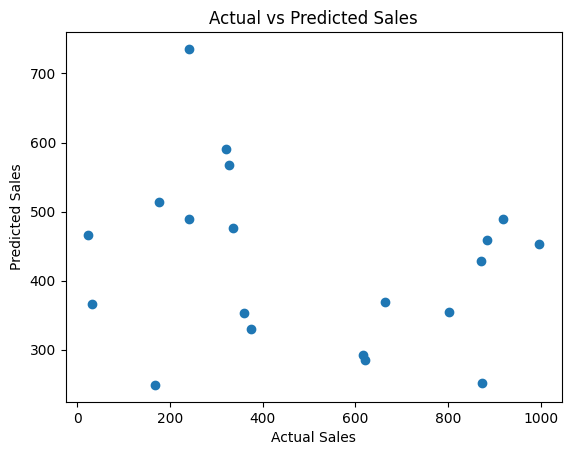

In [12]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

<Axes: title={'center': 'Feature Importance for Sales Prediction'}>

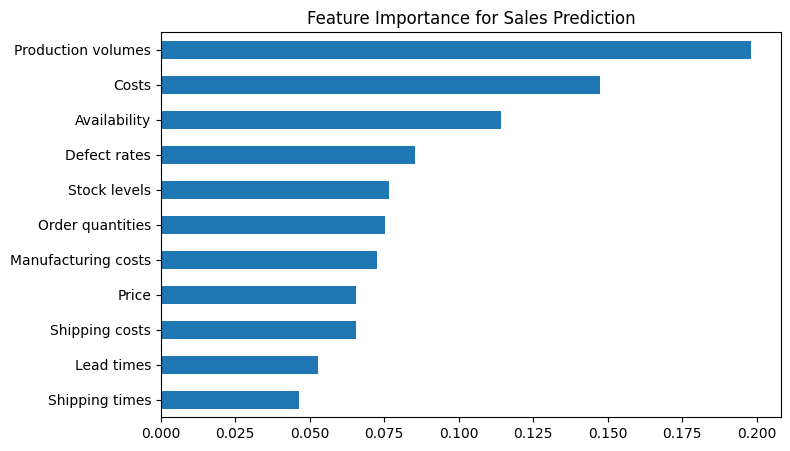

In [13]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(8,5),
    title="Feature Importance for Sales Prediction"
)

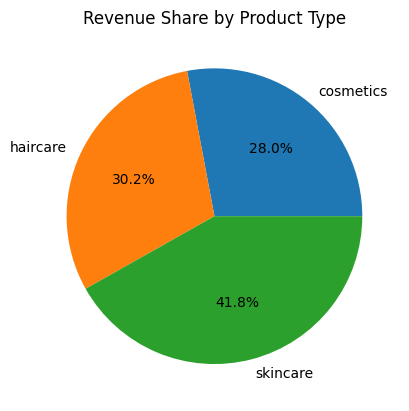

In [14]:
revenue = df.groupby("Product type")["Revenue generated"].sum()

plt.figure()
revenue.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue Share by Product Type")
plt.ylabel("")
plt.show()

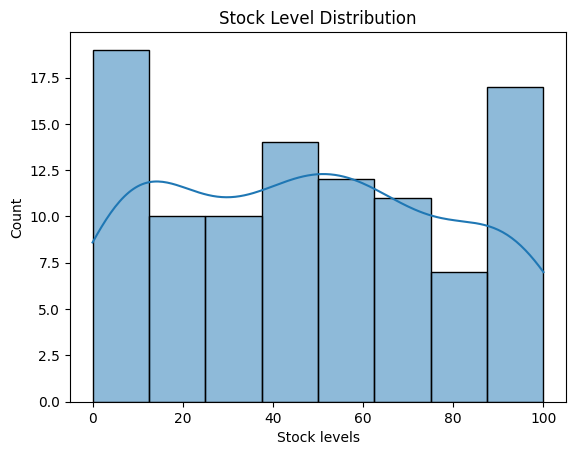

In [15]:
plt.figure()
sns.histplot(df["Stock levels"], kde=True)
plt.title("Stock Level Distribution")
plt.show()

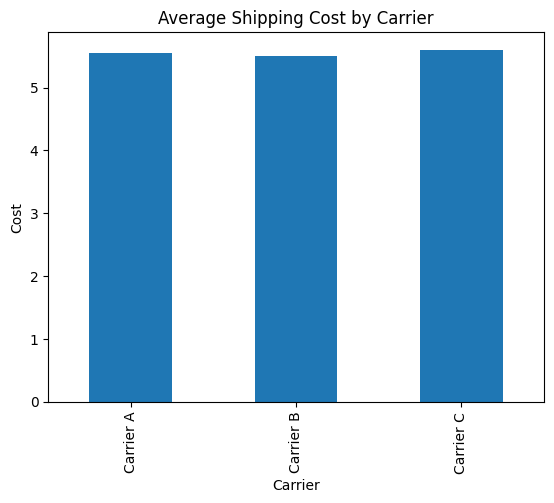

In [16]:
carrier_cost = df.groupby("Shipping carriers")["Shipping costs"].mean()

plt.figure()
carrier_cost.plot(kind='bar')
plt.title("Average Shipping Cost by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Cost")
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3079/173036316.py:4: SyntaxWarning: invalid escape sequence '\d'
  key=lambda x: x.str.extract('(\d+)').astype(int)[0]


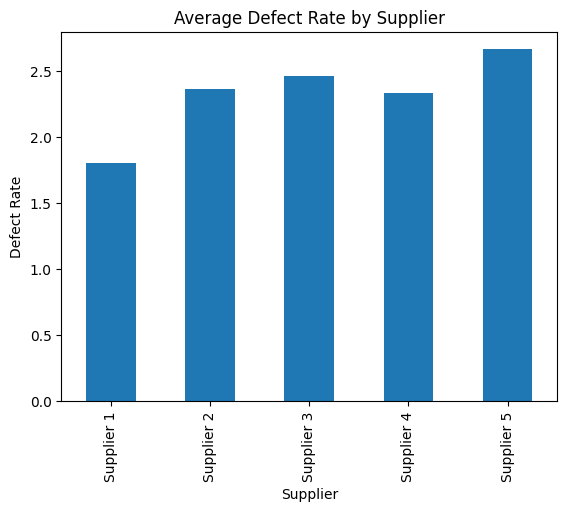

In [17]:
supplier_defects = df.groupby("Supplier name")["Defect rates"].mean()

supplier_defects = supplier_defects.sort_index(
    key=lambda x: x.str.extract('(\d+)').astype(int)[0]
)

plt.figure()
supplier_defects.plot(kind='bar')

plt.title("Average Defect Rate by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Defect Rate")

plt.show()

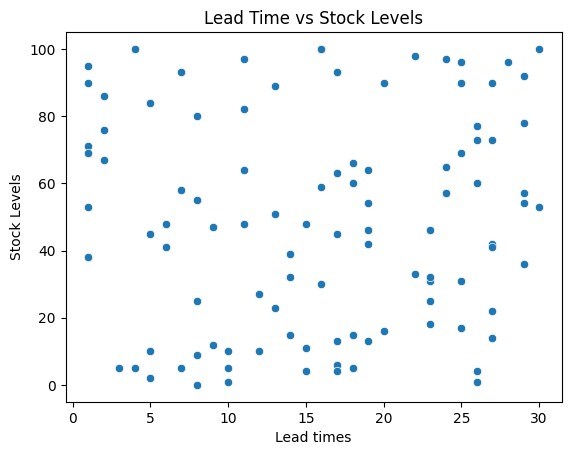

In [18]:
plt.figure()
sns.scatterplot(x=df["Lead times"], y=df["Stock levels"])
plt.title("Lead Time vs Stock Levels")
plt.xlabel("Lead times")
plt.ylabel("Stock Levels")
plt.show()

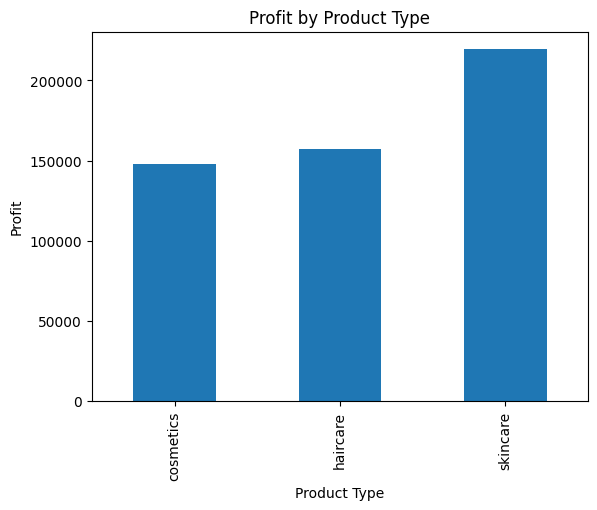

In [19]:
profit_product = df.groupby("Product type")["Profit"].sum()

plt.figure()
profit_product.plot(kind='bar')
plt.title("Profit by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Profit")
plt.show()

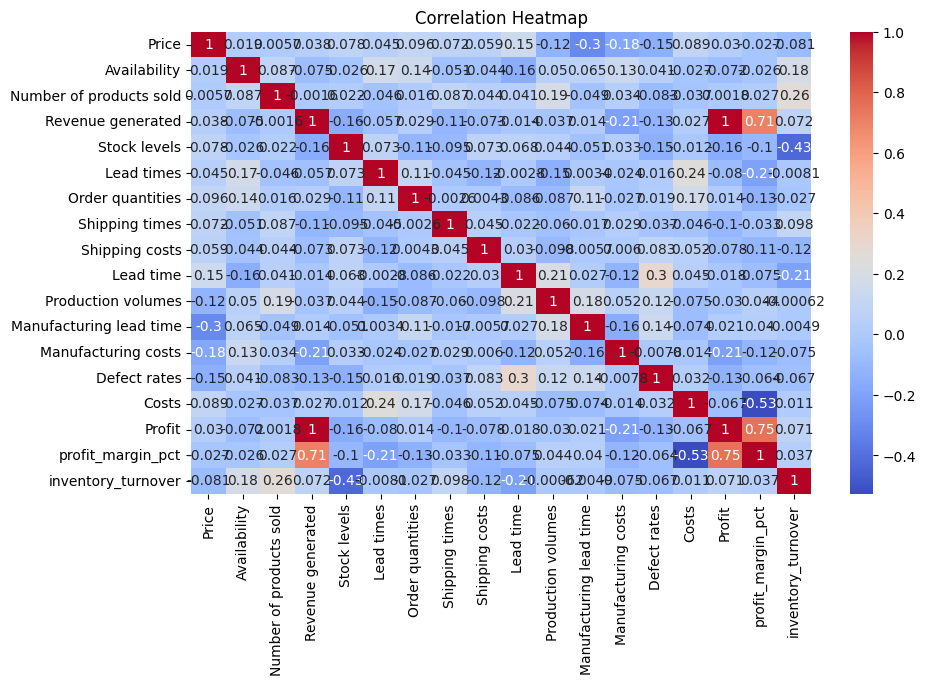

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

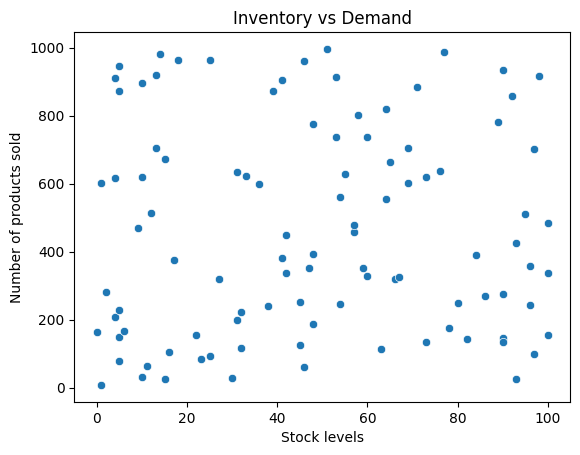

In [21]:
plt.figure()
sns.scatterplot(x=df["Stock levels"], y=df["Number of products sold"])
plt.title("Inventory vs Demand")
plt.show()